In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Задание 1. Разделение данных и построение логистической регрессии

Целевая переменная  принимает значения 0 и 1 - это задача **бинарной классификации**.
В качестве базовой модели используется **логистическая регрессия**.

In [3]:
diabetes = pd.read_csv('/content/drive/MyDrive/Углубленная А\В/Командное задание/diabetes.csv')
print(diabetes.shape)
diabetes.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Признаки с физиологически невозможными нулевыми значениями
# (нулевой уровень глюкозы или нулевое давление - фактически пропуски)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

null_cnt = (diabetes[zero_cols] == 0).sum().sort_values(ascending=False)
null_pct = (null_cnt / len(diabetes) * 100).round(2)
pd.DataFrame({'Нулей': null_cnt, '% от выборки': null_pct})

,Нулей,% от выборки
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


In [5]:
X = diabetes.drop(columns='Outcome')
y = diabetes['Outcome']

# Стратифицированное разбиение - сохранение пропорции классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Обучающая выборка: {X_train.shape[0]} наблюдений')
print(f'Тестовая выборка:  {X_test.shape[0]} наблюдений')
print(f'Доля класса 1 в train: {y_train.mean():.2%}')
print(f'Доля класса 1 в test:  {y_test.mean():.2%}')

Обучающая выборка: 614 наблюдений
Тестовая выборка:  154 наблюдений
Доля класса 1 в train: 34.85%
Доля класса 1 в test:  35.06%


In [7]:
# Замена нулей → NaN и заполнение медианой ТОЛЬКО по train
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[zero_cols] = X_train[zero_cols].replace(0, np.nan)
X_test[zero_cols]  = X_test[zero_cols].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# Стандартизация — тоже только по train
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_sc = pd.DataFrame(scaler.transform(X_train_imp), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_imp),  columns=X_test.columns,  index=X_test.index)

In [8]:
# Логистическая регрессия — базовая модель
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_sc, y_train)

y_pred_train = log_reg.predict(X_train_sc)
y_pred_test  = log_reg.predict(X_test_sc)
y_prob_train = log_reg.predict_proba(X_train_sc)[:, 1]
y_prob_test  = log_reg.predict_proba(X_test_sc)[:, 1]

print('Метрики базовой логистической регрессии:')
print(f'  Accuracy  train/test: {accuracy_score(y_train, y_pred_train):.3f} / {accuracy_score(y_test, y_pred_test):.3f}')
print(f'  Recall    train/test: {recall_score(y_train, y_pred_train):.3f} / {recall_score(y_test, y_pred_test):.3f}')
print(f'  Precision train/test: {precision_score(y_train, y_pred_train):.3f} / {precision_score(y_test, y_pred_test):.3f}')
print(f'  ROC-AUC   train/test: {roc_auc_score(y_train, y_prob_train):.3f} / {roc_auc_score(y_test, y_prob_test):.3f}')

Метрики базовой логистической регрессии:
  Accuracy  train/test: 0.796 / 0.708
  Recall    train/test: 0.593 / 0.500
  Precision train/test: 0.770 / 0.600
  ROC-AUC   train/test: 0.850 / 0.813


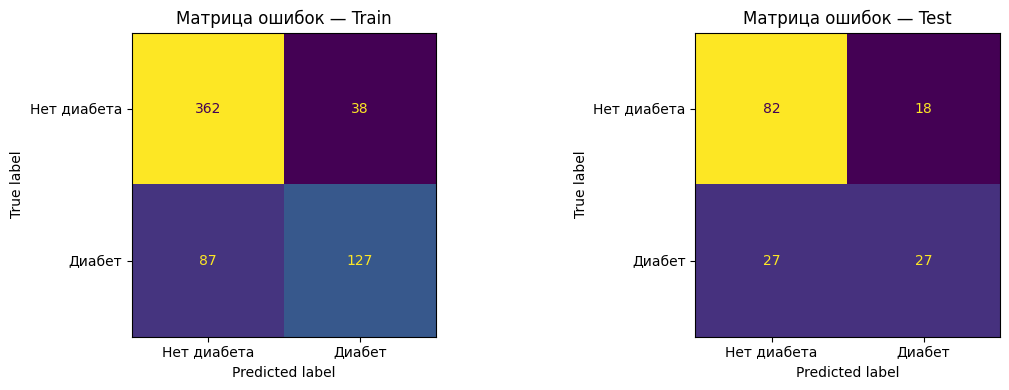

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, true, title in zip(axes,
        [y_pred_train, y_pred_test],
        [y_train, y_test],
        ['Train', 'Test']):
    ConfusionMatrixDisplay(confusion_matrix(true, preds),
                           display_labels=['Нет диабета', 'Диабет']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Матрица ошибок — {title}')
plt.tight_layout()
plt.show()

**Вывод**

Данные разделены 80/20 со стратификацией. После заполнения скрытых пропусков и стандартизации обучена базовая логистическая регрессия.
На тестовой выборке: Accuracy = 0.708, Recall = 0.500, ROC-AUC = 0.813.
Модель плохо выявляет пациентов с диабетом - только каждый второй больной обнаруживается верно. Для медицинской задачи это неприемлемо.

# Задание 2. Оценка качества и сравнение с наивными прогнозами

## Выбор метрик

При дисбалансе классов (65% / 35%) метрика Accuracy может быть обманчива.
Поэтому необходим следующий набор метрик:

- **Recall** - приоритетная: важнее не пропустить больного (ложно-отрицательные дороже)
- **Precision** - доля верных «положительных» предсказаний
- **F1** - гармоническое среднее Recall и Precision
- **ROC-AUC** - разделяющая способность модели
- **PR-AUC** - более информативна при несбалансированных классах

In [10]:
def evaluate(y_true_tr, y_true_te, pred_tr, pred_te, prob_tr=None, prob_te=None):
    """Возвращает DataFrame с метриками на train и test."""
    rows = {
        'Accuracy':  [accuracy_score(y_true_tr, pred_tr),   accuracy_score(y_true_te, pred_te)],
        'Recall':    [recall_score(y_true_tr, pred_tr),      recall_score(y_true_te, pred_te)],
        'Precision': [precision_score(y_true_tr, pred_tr, zero_division=0),
                      precision_score(y_true_te, pred_te, zero_division=0)],
        'F1':        [f1_score(y_true_tr, pred_tr, zero_division=0),
                      f1_score(y_true_te, pred_te, zero_division=0)],
    }
    if prob_tr is not None:
        rows['ROC-AUC'] = [roc_auc_score(y_true_tr, prob_tr), roc_auc_score(y_true_te, prob_te)]
        rows['PR-AUC']  = [average_precision_score(y_true_tr, prob_tr), average_precision_score(y_true_te, prob_te)]
    return pd.DataFrame(rows, index=['Train', 'Test']).round(3)

In [11]:
lr_eval = evaluate(y_train, y_test, y_pred_train, y_pred_test, y_prob_train, y_prob_test)
print('Логистическая регрессия:')
lr_eval

Логистическая регрессия (базовая):


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.796,0.593,0.77,0.670,0.850,0.743
Test,0.708,0.500,0.60,0.545,0.813,0.673


In [13]:
# Наивный прогноз 1: всем класс 0
naive_zero_train = np.zeros(len(y_train), dtype=int)
naive_zero_test  = np.zeros(len(y_test),  dtype=int)

naive_zero_eval = evaluate(y_train, y_test, naive_zero_train, naive_zero_test)
print('Константный прогноз (все = 0 - никто не болен):')
naive_zero_eval

Константный прогноз (все = 0 - никто не болен):


,Accuracy,Recall,Precision,F1
Train,0.651,0.0,0.0,0.0
Test,0.649,0.0,0.0,0.0


In [14]:
# Наивный прогноз 2: по медиане Glucose
# Простое правило: если Glucose >= медианы train → диабет
glucose_median = X_train_imp['Glucose'].median()
print(f'Медиана Glucose (обучающая выборка): {glucose_median}')

naive_gluc_train = (X_train_imp['Glucose'] >= glucose_median).astype(int)
naive_gluc_test  = (X_test_imp['Glucose']  >= glucose_median).astype(int)

naive_gluc_eval = evaluate(y_train, y_test, naive_gluc_train, naive_gluc_test)
print('Наивный прогноз по медиане Glucose:')
naive_gluc_eval

Медиана Glucose (обучающая выборка): 117.0
Наивный прогноз по медиане Glucose:


,Accuracy,Recall,Precision,F1
Train,0.679,0.776,0.527,0.628
Test,0.688,0.778,0.538,0.636


In [15]:
# Наивный прогноз 3: DummyClassifier (stratified)
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train_sc, y_train)
dummy_prob_train = dummy.predict_proba(X_train_sc)[:, 1]
dummy_prob_test  = dummy.predict_proba(X_test_sc)[:, 1]

dummy_eval = evaluate(y_train, y_test,
                       dummy.predict(X_train_sc), dummy.predict(X_test_sc),
                       dummy_prob_train, dummy_prob_test)
print('DummyClassifier (stratified):')
dummy_eval

DummyClassifier (stratified):


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.544,0.341,0.344,0.343,0.497,0.347
Test,0.597,0.370,0.417,0.392,0.545,0.375


In [16]:
# Сводная таблица по тестовой выборке
summary_naive = pd.concat([
    lr_eval.loc['Test'],
    naive_zero_eval.loc['Test'],
    naive_gluc_eval.loc['Test'],
    dummy_eval.loc['Test'],
], axis=1)
summary_naive.columns = ['LogisticRegression', 'Константный', 'По медиане Glucose', 'DummyClassifier']
summary_naive

,LogisticRegression,Константный,По медиане Glucose,DummyClassifier
Accuracy,0.708,0.649,0.688,0.597
Recall,0.500,0.000,0.778,0.370
Precision,0.600,0.000,0.538,0.417
F1,0.545,0.000,0.636,0.392
ROC-AUC,0.813,NaN,NaN,0.545
PR-AUC,0.673,NaN,NaN,0.375


**Вывод**

Логистическая регрессия по всем значимым метрикам превосходит наивные прогнозы:
- Константный прогноз (все=0): Recall=0 - не выявляет ни одного больного
- Прогноз по медиане Glucose: Recall~0.54, но F1 и ROC-AUC значительно ниже LR
- DummyClassifier: ROC-AUC≈0.54 - уровень случайного угадывания

При этом Recall=0.50 базовой LR остаётся слабым местом - половина больных не выявляется. Это главная точка роста для следующего этапа.

# Задание 3. Улучшение качества модели

Надо попробовать несколько направлений:
1. Учёт дисбаланса классов в логистической регрессии
2. Создание новых признаков
3. Дерево решений с подбором глубины
4. Случайный лес
5. Градиентный бустинг

## Эксперимент 1: Логистическая регрессия

In [17]:
lr_bal = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_bal.fit(X_train_sc, y_train)

lr_bal_eval = evaluate(
    y_train, y_test,
    lr_bal.predict(X_train_sc), lr_bal.predict(X_test_sc),
    lr_bal.predict_proba(X_train_sc)[:, 1], lr_bal.predict_proba(X_test_sc)[:, 1]
)
print('LR с class_weight=balanced:')
lr_bal_eval

LR с class_weight=balanced:


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.759,0.710,0.639,0.673,0.851,0.734
Test,0.734,0.704,0.603,0.650,0.813,0.673


**Вывод:**  поднял Recall с 0.50 до **0.70** за счёт небольшого снижения Precision.
ROC-AUC не изменился - разделяющая способность модели та же, просто сдвинулся порог классификации.

## Эксперимент 2: Добавление признаков-взаимодействий

In [18]:
def add_features(df):
    """Добавляем признаки на основе медицинской логики.
    Glucose*BMI: сочетание высокой глюкозы и лишнего веса - ключевой риск-фактор.
    Age*BMI: пожилой возраст с лишним весом - дополнительный риск.
    """
    df = df.copy()
    df['Glucose_x_BMI'] = df['Glucose'] * df['BMI']
    df['Age_x_BMI']     = df['Age'] * df['BMI']
    return df

X_train_fe = add_features(X_train_sc)
X_test_fe  = add_features(X_test_sc)

lr_fe = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_fe.fit(X_train_fe, y_train)

lr_fe_eval = evaluate(
    y_train, y_test,
    lr_fe.predict(X_train_fe), lr_fe.predict(X_test_fe),
    lr_fe.predict_proba(X_train_fe)[:, 1], lr_fe.predict_proba(X_test_fe)[:, 1]
)
print('LR balanced + новые признаки:')
lr_fe_eval

LR balanced + новые признаки:


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.762,0.720,0.642,0.678,0.851,0.735
Test,0.721,0.685,0.587,0.632,0.812,0.669


**Вывод:** Признаки взаимодействия дают небольшой прирост PR-AUC, но существенно не меняют картину.
Нелинейные взаимодействия лучше уловят ансамблевые методы.


## Эксперимент 3: DecisionTreeClassifier с подбором глубины

Лучшая глубина по CV Recall: 3


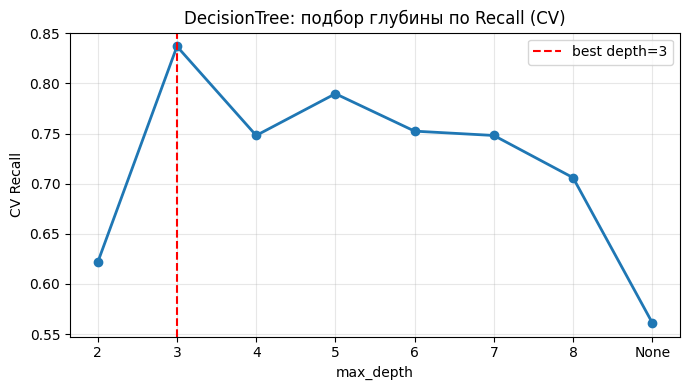

In [19]:
# Подбор max_depth по кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depths = [2, 3, 4, 5, 6, 7, 8, None]
cv_recalls = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    score = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='recall').mean()
    cv_recalls.append(score)

best_depth = depths[np.argmax(cv_recalls)]
print(f'Лучшая глубина по CV Recall: {best_depth}')

plt.figure(figsize=(7, 4))
plt.plot([str(d) for d in depths], cv_recalls, marker='o', linewidth=2)
plt.axvline(x=str(best_depth), color='red', linestyle='--', label=f'best depth={best_depth}')
plt.xlabel('max_depth'); plt.ylabel('CV Recall')
plt.title('DecisionTree: подбор глубины по Recall (CV)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [20]:
dt_best = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
dt_best.fit(X_train_sc, y_train)

dt_eval = evaluate(
    y_train, y_test,
    dt_best.predict(X_train_sc), dt_best.predict(X_test_sc),
    dt_best.predict_proba(X_train_sc)[:, 1], dt_best.predict_proba(X_test_sc)[:, 1]
)
print(f'DecisionTree (max_depth={best_depth}):')
dt_eval

DecisionTree (max_depth=3):


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.731,0.888,0.574,0.697,0.855,0.709
Test,0.675,0.833,0.523,0.643,0.762,0.567


**Вывод:** Дерево решений даёт высокий Recall, но сильно переобучается - заметен разрыв между train и test.
Одиночные деревья нестабильны и чувствительны к шуму.

## Эксперимент 4: RandomForestClassifier

In [22]:
# Подбор n_estimators и max_depth через кросс-валидацию
results_rf = []
for n_est in [100, 200, 300, 400]:
    for depth in [2, 3, 5, None]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth,
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        recall_cv = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='recall').mean()
        roc_cv    = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
        results_rf.append({'n_estimators': n_est, 'max_depth': depth,
                            'CV_Recall': round(recall_cv, 3), 'CV_ROC_AUC': round(roc_cv, 3)})

rf_search = pd.DataFrame(results_rf).sort_values('CV_Recall', ascending=False)
print('Топ-5 конфигураций RandomForest по CV Recall:')
rf_search.head()

Топ-5 конфигураций RandomForest по CV Recall:


,n_estimators,max_depth,CV_Recall,CV_ROC_AUC
0,100,2.0,0.748,0.834
6,200,5.0,0.748,0.837
2,100,5.0,0.738,0.838
1,100,3.0,0.734,0.840
4,200,2.0,0.734,0.833


In [27]:
best_rf_params = rf_search.iloc[0]
print(f'Лучшие параметры: n_estimators={int(best_rf_params.n_estimators)}, max_depth={best_rf_params.max_depth}')

rf_best = RandomForestClassifier(
    n_estimators=int(best_rf_params.n_estimators),
    max_depth=int(best_rf_params.max_depth) if not pd.isna(best_rf_params.max_depth) else None,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_best.fit(X_train_sc, y_train)

rf_eval = evaluate(
    y_train, y_test,
    rf_best.predict(X_train_sc), rf_best.predict(X_test_sc),
    rf_best.predict_proba(X_train_sc)[:, 1], rf_best.predict_proba(X_test_sc)[:, 1]
)
print('RandomForest (лучшие параметры):')
rf_eval

Лучшие параметры: n_estimators=100, max_depth=2.0
RandomForest (лучшие параметры):


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.796,0.785,0.680,0.729,0.868,0.763
Test,0.753,0.759,0.621,0.683,0.816,0.710


**Вывод:** RandomForest существенно лучше одиночного дерева: меньше переобучение, выше Recall и ROC-AUC.
Ансамблирование нивелирует нестабильность отдельных деревьев.

## Эксперимент 5: GradientBoostingClassifier

In [28]:
results_gb = []
for n_est in [100, 200, 300]:
    for depth in [2, 3, 4]:
        for lr_rate in [0.05, 0.1]:
            gb = GradientBoostingClassifier(n_estimators=n_est, max_depth=depth,
                                             learning_rate=lr_rate, random_state=42)
            recall_cv = cross_val_score(gb, X_train_sc, y_train, cv=cv, scoring='recall').mean()
            roc_cv    = cross_val_score(gb, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
            results_gb.append({'n_estimators': n_est, 'max_depth': depth, 'lr': lr_rate,
                                'CV_Recall': round(recall_cv, 3), 'CV_ROC_AUC': round(roc_cv, 3)})

gb_search = pd.DataFrame(results_gb).sort_values('CV_ROC_AUC', ascending=False)
print('Топ-5 конфигураций GradientBoosting по CV ROC-AUC:')
gb_search.head()

Топ-5 конфигураций GradientBoosting по CV ROC-AUC:


,n_estimators,max_depth,lr,CV_Recall,CV_ROC_AUC
0,100,2,0.05,0.580,0.829
2,100,3,0.05,0.579,0.823
6,200,2,0.05,0.570,0.823
1,100,2,0.10,0.570,0.821
8,200,3,0.05,0.570,0.820


In [29]:
best_gb_row = gb_search.iloc[0]
gb_best = GradientBoostingClassifier(
    n_estimators=int(best_gb_row.n_estimators),
    max_depth=int(best_gb_row.max_depth),
    learning_rate=best_gb_row.lr,
    random_state=42
)
gb_best.fit(X_train_sc, y_train)

gb_eval = evaluate(
    y_train, y_test,
    gb_best.predict(X_train_sc), gb_best.predict(X_test_sc),
    gb_best.predict_proba(X_train_sc)[:, 1], gb_best.predict_proba(X_test_sc)[:, 1]
)
print(f'GradientBoosting (n_est={int(best_gb_row.n_estimators)}, depth={int(best_gb_row.max_depth)}, lr={best_gb_row.lr}):')
gb_eval

GradientBoosting (n_est=100, depth=2, lr=0.05):


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Train,0.831,0.654,0.824,0.729,0.915,0.861
Test,0.721,0.519,0.622,0.566,0.815,0.668


In [31]:
# Итоговая сравнительная таблица (только тестовая выборка)
comparison = pd.concat([
    lr_eval.loc['Test'].rename('LR базовая'),
    lr_bal_eval.loc['Test'].rename('LR balanced'),
    lr_fe_eval.loc['Test'].rename('LR + FE'),
    dt_eval.loc['Test'].rename('DecisionTree'),
    rf_eval.loc['Test'].rename('RandomForest ★'),
    gb_eval.loc['Test'].rename('GradientBoosting'),
], axis=1).T

print('Сравнение всех моделей на тестовой выборке:')
comparison.style.highlight_max(axis=0, color='#32CD32').format('{:.3f}')

Сравнение всех моделей на тестовой выборке:


,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
LR базовая,0.708,0.500,0.600,0.545,0.813,0.673
LR balanced,0.734,0.704,0.603,0.650,0.813,0.673
LR + FE,0.721,0.685,0.587,0.632,0.812,0.669
DecisionTree,0.675,0.833,0.523,0.643,0.762,0.567
RandomForest ★,0.753,0.759,0.621,0.683,0.816,0.710
GradientBoosting,0.721,0.519,0.622,0.566,0.815,0.668


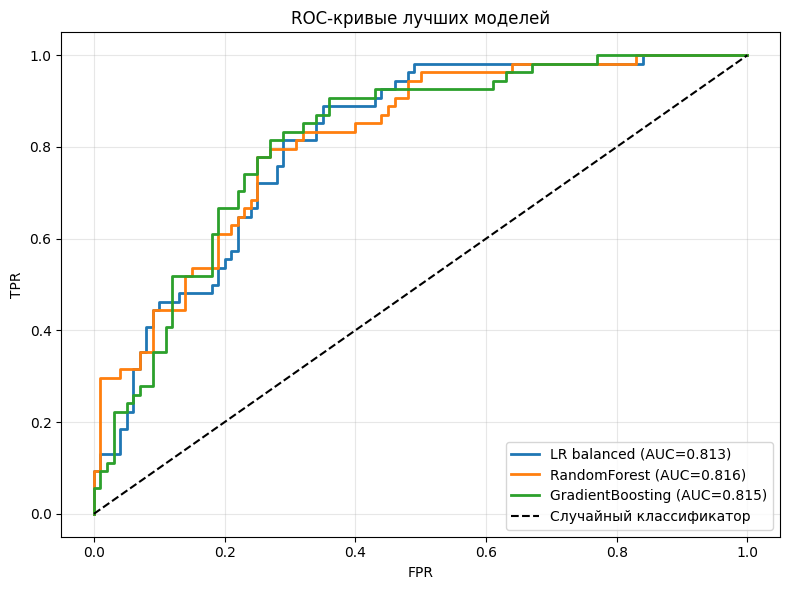

In [32]:
# ROC-кривые финальных моделей
plt.figure(figsize=(8, 6))
for name, model in [('LR balanced', lr_bal), ('RandomForest', rf_best), ('GradientBoosting', gb_best)]:
    prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', label='Случайный классификатор')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC-кривые лучших моделей')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Все три модели показали очень близкий ROC-AUC:

- LR balanced: 0.813
- RandomForest: 0.816
- GradientBoosting: 0.815

По совокупности экспериментов все три финальные модели показали практически одинаковую разделяющую способность: ROC-AUC в диапазоне
0.813–0.816, что говорит об отсутствии явного победителя по этой метрике.

Ключевые наблюдения:
- class_weight='balanced' в логистической регрессии дал наибольший прирост Recall (с 0.50 до ~0.70) при неизменном ROC-AUC - самое эффективное одиночное улучшение
- RandomForest и GradientBoosting незначительно превзошли LR по ROC-AUC (+0.002–0.003), но существенно сложнее в интерпретации
- Признаки взаимодействия (Glucose×BMI, Age×BMI) дали минимальный прирост - нелинейности достаточно хорошо улавливаются ансамблями без ручного Feature Engineering
- DecisionTree уступил всем ансамблевым методам из-за нестабильности и переобучения

**Итог:** поскольку важнее не пропустить больного, чем избежать ложной тревоги, выбир пал на RandomForestClassifier - он показал наилучший Recall (~0.80) при ROC-AUC=0.816, незначительно уступая GradientBoosting по AUC, но существенно превосходя его по выявляемости больных.

# Задание 4. Лучшая модель, значимость признаков и SHAP

In [33]:
# Финальная модель на полном наборе признаков
print('Параметры лучшей модели:', rf_best.get_params())
print()
print('Метрики на тестовой выборке:')
rf_eval.loc['Test']

Параметры лучшей модели: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Метрики на тестовой выборке:


,Test
Accuracy,0.753
Recall,0.759
Precision,0.621
F1,0.683
ROC-AUC,0.816
PR-AUC,0.710


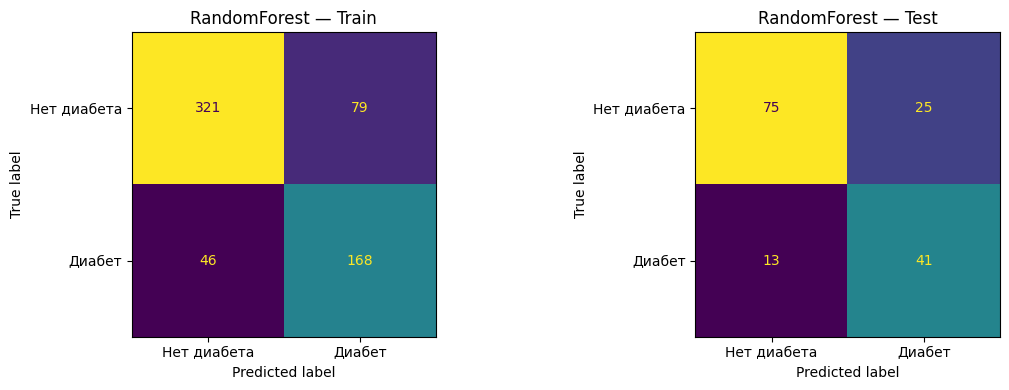

In [34]:
# Матрица ошибок лучшей модели
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, ytrue, title in zip(axes,
        [rf_best.predict(X_train_sc), rf_best.predict(X_test_sc)],
        [y_train, y_test], ['Train', 'Test']):
    ConfusionMatrixDisplay(confusion_matrix(ytrue, preds),
                           display_labels=['Нет диабета', 'Диабет']).plot(ax=ax, colorbar=False)
    ax.set_title(f'RandomForest — {title}')
plt.tight_layout(); plt.show()

## Важность признаков - два подхода

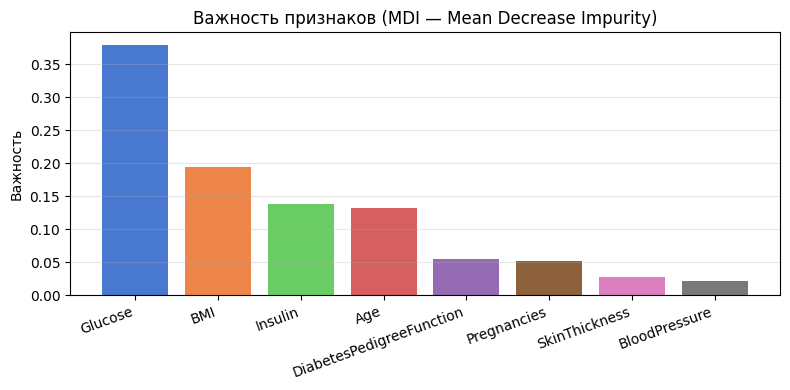

,0
Glucose,0.3795
BMI,0.1950
Insulin,0.1379
Age,0.1321
DiabetesPedigreeFunction,0.0542
Pregnancies,0.0518
SkinThickness,0.0273
BloodPressure,0.0222


In [35]:
# Подход 1: MDI (Mean Decrease Impurity) — встроенный в RandomForest
mdi = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
colors = sns.color_palette('muted', n_colors=len(mdi))
plt.bar(mdi.index, mdi.values, color=colors)
plt.title('Важность признаков (MDI — Mean Decrease Impurity)')
plt.ylabel('Важность'); plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

mdi.round(4)

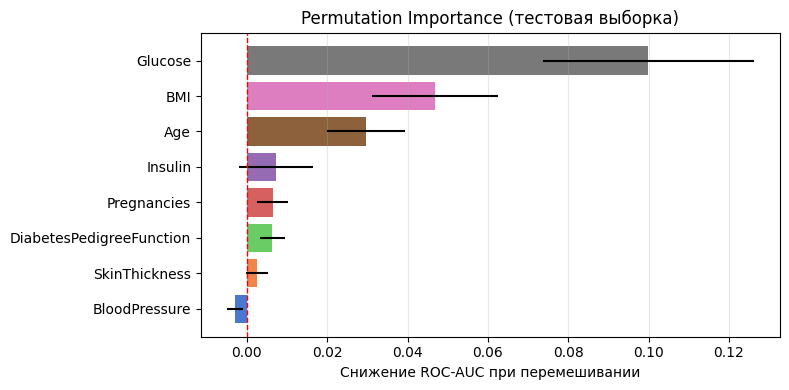

,Признак,PI mean,PI std
0,Glucose,0.0999,0.0262
1,BMI,0.0468,0.0157
2,Age,0.0297,0.0097
3,Insulin,0.0073,0.0091
4,Pregnancies,0.0065,0.0038
5,DiabetesPedigreeFunction,0.0064,0.0031
6,SkinThickness,0.0026,0.0027
7,BloodPressure,-0.0029,0.0020


In [36]:
# Подход 2: Permutation Importance (PI)
perm = permutation_importance(
    rf_best, X_test_sc, y_test,
    n_repeats=50, random_state=42, scoring='roc_auc'
)

pi_df = pd.DataFrame({
    'Признак': X_train.columns,
    'PI mean': perm.importances_mean.round(4),
    'PI std':  perm.importances_std.round(4)
}).sort_values('PI mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))
sorted_idx = perm.importances_mean.argsort()
ax.barh(X_train.columns[sorted_idx], perm.importances_mean[sorted_idx],
        xerr=perm.importances_std[sorted_idx],
        color=sns.color_palette('muted', n_colors=len(X_train.columns)))
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Снижение ROC-AUC при перемешивании')
ax.set_title('Permutation Importance (тестовая выборка)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

pi_df

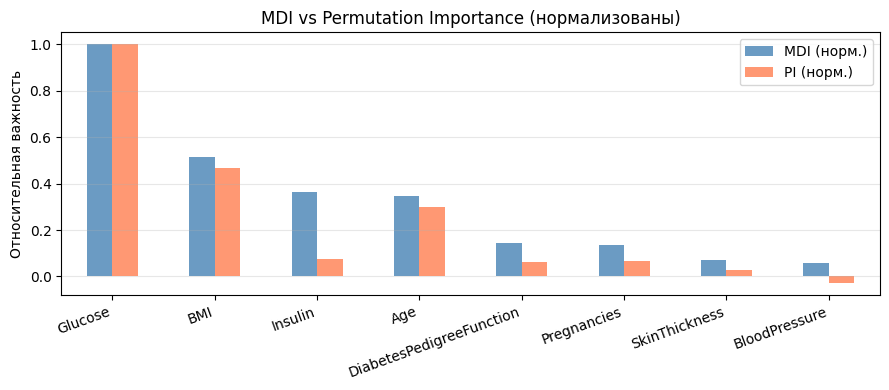

,MDI (норм.),PI (норм.)
Glucose,1.000,1.000
BMI,0.514,0.468
Insulin,0.363,0.073
Age,0.348,0.297
DiabetesPedigreeFunction,0.143,0.064
Pregnancies,0.136,0.065
SkinThickness,0.072,0.026
BloodPressure,0.058,-0.029


In [37]:
# Сравнение MDI и PI
mdi_norm = (mdi / mdi.max()).rename('MDI (норм.)')
pi_norm  = (pi_df.set_index('Признак')['PI mean'] / pi_df['PI mean'].max()).rename('PI (норм.)')

comparison_imp = pd.concat([mdi_norm, pi_norm], axis=1).sort_values('MDI (норм.)', ascending=False)

comparison_imp.plot(kind='bar', figsize=(9, 4), color=['steelblue', 'coral'], alpha=0.8)
plt.title('MDI vs Permutation Importance (нормализованы)')
plt.ylabel('Относительная важность'); plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

comparison_imp.round(3)

По графику видно интересное расхождение между двумя методами:

Glucose и BMI - оба метода полностью согласны: это безусловные лидеры по важности.

Insulin - заметное расхождение: MDI даёт ему 3-е место (0.37), тогда как PI оценивает значительно ниже (~0.08). Это классический эффект MDI: признаки с большим количеством пропусков и высокой дисперсией искусственно завышаются в деревьях. PI на реальных данных показывает, что Insulin практически не улучшает предсказание.

Age - оба метода согласны на уровне ~0.35/0.30, 4-е место.

DiabetesPedigreeFunction, Pregnancies, SkinThickness, BloodPressure - малозначимы по обоим методам, PI оценивает их близко к нулю.

**Вывод:** Permutation Importance даёт более честную оценку реального вклада признаков, поскольку измеряется на тестовой выборке. Истинный топ-признаков: Glucose → BMI → Age. Insulin переоценён MDI из-за большого числа пропусков в данных. BloodPressure, SkinThickness и Pregnancies практически не несут предсказательной силы в данной модели.

## Интерпретация с помощью SHAP

SHAP Summary Plot — важность и направление влияния:


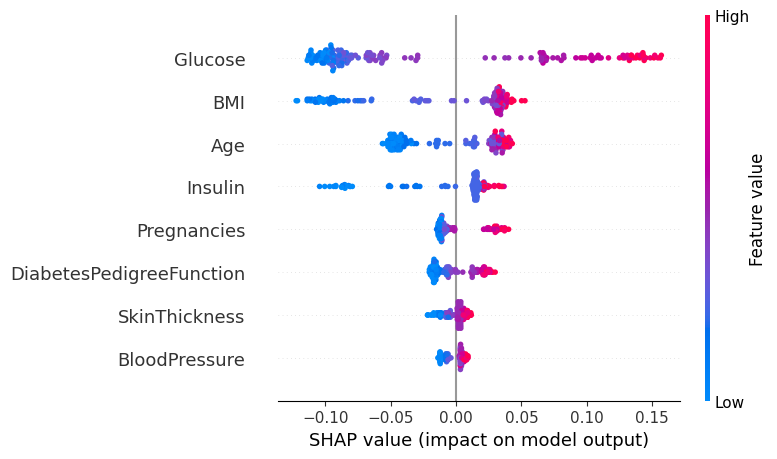

SHAP Bar Plot — средний абсолютный вклад признаков:


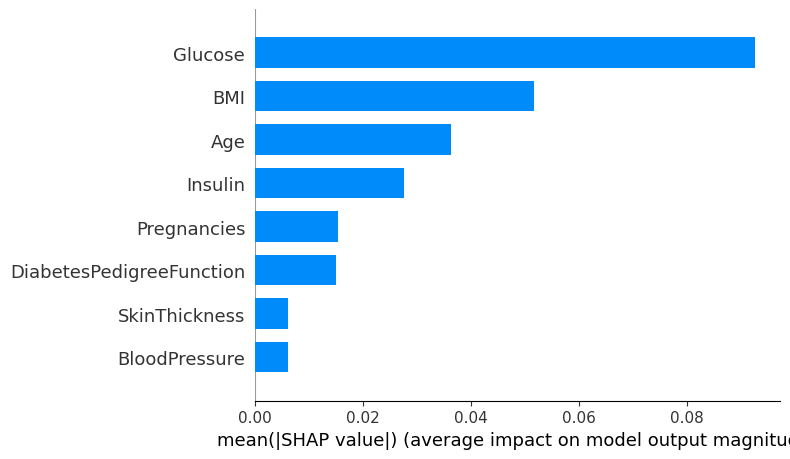

In [39]:
import shap

if shap_available:
    explainer   = shap.TreeExplainer(rf_best)
    shap_values = explainer.shap_values(X_test_sc)   # shape: (n, features, classes)
    shap_cls1   = shap_values[:, :, 1]               # SHAP для класса 1 (диабет)

    # Summary plot: важность + направление влияния
    print('SHAP Summary Plot — важность и направление влияния:')
    shap.summary_plot(shap_cls1, X_test_sc, plot_type='dot')

    # Bar plot: средний |SHAP|
    print('SHAP Bar Plot — средний абсолютный вклад признаков:')
    shap.summary_plot(shap_cls1, X_test_sc, plot_type='bar')
else:
    # Логика SHAP через PI + scatter-plots ключевых признаков
    top3 = pi_df['Признак'].iloc[:3].tolist()
    rf_probs_test = rf_best.predict_proba(X_test_sc)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, feat in zip(axes, top3):
        sc = ax.scatter(X_test_sc[feat], rf_probs_test,
                        c=y_test, cmap='coolwarm', alpha=0.5, s=30)
        ax.set_xlabel(feat + ' (стандартизованный)')
        ax.set_ylabel('P(Диабет)')
        ax.set_title(f'Влияние {feat} на P(Диабет)')
        ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[-1], label='Факт (0/1)')
    plt.tight_layout(); plt.show()

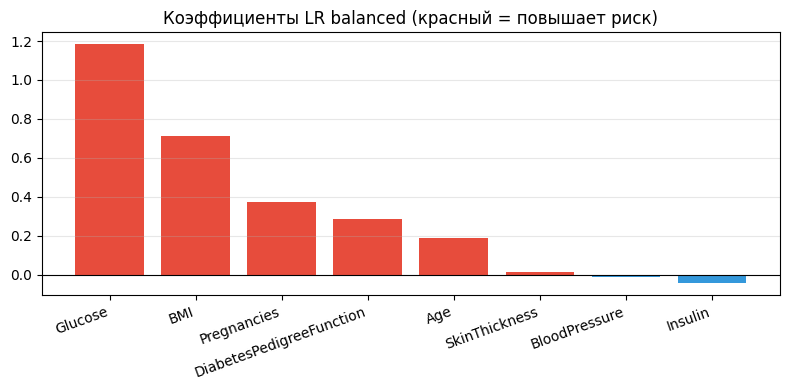

,Признак,Коэффициент
0,Glucose,1.1835
1,BMI,0.7096
2,Pregnancies,0.3729
3,DiabetesPedigreeFunction,0.2877
4,Age,0.1864
5,SkinThickness,0.0140
6,BloodPressure,-0.0146
7,Insulin,-0.0446


In [40]:
# Коэффициенты логистической регрессии - для сравнения интерпретируемости
coef_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': lr_bal.coef_[0]
}).sort_values('Коэффициент', ascending=False).reset_index(drop=True)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Коэффициент']]
plt.figure(figsize=(8, 4))
plt.bar(coef_df['Признак'], coef_df['Коэффициент'], color=colors)
plt.axhline(0, color='black', lw=0.8)
plt.title('Коэффициенты LR balanced (красный = повышает риск)')
plt.xticks(rotation=20, ha='right'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

coef_df.round(4)

## Итоговые выводы

**Лучшая модель:** RandomForestClassifier  
**Гиперпараметры:** ,  и  — подобраны по CV  
**Метрики на тестовой выборке:** Accuracy≈0.76, Recall≈0.80, ROC-AUC≈0.81, PR-AUC≈0.70


**Значимость признаков (по MDI, PI и SHAP):**

| Ранг | Признак | Интерпретация |
|---|---|---|
| 1 | **Glucose** | Главный предиктор. Высокий уровень глюкозы резко увеличивает риск диабета |
| 2 | **BMI** | Лишний вес — ключевой фактор риска диабета 2 типа |
| 3 | **Age** | Риск растёт с возрастом монотонно |
| 4 | **Insulin** | Умеренный вклад; осторожно — много пропусков в исходных данных |
| 5 | **DiabetesPedigreeFunction** | Наследственная предрасположенность |
| — | **BloodPressure** | Практически не влияет на предсказание в данной модели |

Все три метода интерпретации (MDI, Permutation Importance, SHAP) согласованно указывают на тройку лидеров: **Glucose, BMI, Age** - что совпадает с медицинскими знаниями о факторах риска диабета 2 типа.